In [ ]:
# ===============================================
# Hybrid PV–CSP–TES GA (stepped + threaded + timed)
# ===============================================
import random
import time
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
from deap import base, creator, tools, algorithms

# Thread pool (avoids Windows pickling issues)
from multiprocessing.dummy import Pool as ThreadPool
import multiprocessing as mp

# == Import your models ==
from models.pv_model import run_pvsam
from models.csp_model import run_basic_mspt
from models.dispatch_opt import optimize_dispatch, calculate_firm_bonus
from capex_opex.excel_capex_opex import calc_capex_opex
from models.lcoe import calculate_lcoe_constant

# ------------------------------------------------------------------------------------
# Config
# ------------------------------------------------------------------------------------
excel_file = Path("capex_opex/CAPEX OPEX model CSP-PV MJ2500.xlsx")
random.seed(42)

# Bounds for decision variables: [desired_array_size, P_ref, t_TES_hours]
BOUNDS = [
    (50_000, 250_000),   # PV size (kWdc)
    (25.0, 150.0),       # CSP size (MWe)
    (4, 20)              # TES hours
]

# Discrete step sizes (snapped grid)
STEPS = {
    0: 5_000,   # PV kWdc step (e.g., 5 MWdc)
    1: 5.0,     # CSP MWe step
    2: 2,       # TES hours step
}

TRIAL_LOG = []
PENALTY = 1e12  # penalty added to PPA if constraint violated

# Toggle to use textbook-style discounting windows
USE_TEXTBOOK_FINANCIALS = True

# Financial assumptions
debt = 0.8
equity = 0.2
debt_rate = 0.05
equity_rate = 0.08
tax_rate = 0.25
lifetime_years = 30
construction_years = 2

# ------------------------------------------------------------------------------------
# Utilities (stepping, random stepped init, repair)
# ------------------------------------------------------------------------------------
def _snap(val, step, is_int=False):
    snapped = round(float(val) / step) * step
    return int(snapped) if is_int else float(snapped)

def _rand_step(lo, hi, step, as_int=False):
    n = int(round((hi - lo) / step))
    v = lo + step * random.randint(0, n)
    return int(v) if as_int else float(v)

def _repair(ind):
    # snap each gene to its step & clamp to bounds
    ind[0] = _snap(ind[0], STEPS[0], is_int=True)   # PV kWdc
    ind[1] = _snap(ind[1], STEPS[1], is_int=False)  # CSP MWe
    ind[2] = _snap(ind[2], STEPS[2], is_int=True)   # TES h
    for i, (lo, hi) in enumerate(BOUNDS):
        if ind[i] < lo: ind[i] = lo
        if ind[i] > hi: ind[i] = hi
    return ind

def _feasible_from_vals(pv_kwdc, csp_mwe):
    # Algebraic check: P_ref ≥ 0.25 * (desired_array_size / 1000)
    csp_min = 0.25 * (pv_kwdc / 1000.0)
    return (csp_mwe - csp_min) >= 0.0

# ------------------------------------------------------------------------------------
# System evaluation (cached)
# ------------------------------------------------------------------------------------
@lru_cache(maxsize=256)
def eval_system(desired_array_size, P_ref, t_TES_hours):
    """
    Returns:
        PPA (float), -CF_hybrid (float), g0 (float: feasibility margin)
    """
    # Snap to step grid BEFORE casting (maximizes cache hits)
    desired_array_size = _snap(desired_array_size, STEPS[0], is_int=True)
    P_ref              = _snap(P_ref,             STEPS[1], is_int=False)
    t_TES_hours        = _snap(t_TES_hours,       STEPS[2], is_int=True)

    # Fixed tech parameters
    dc_to_ac_ratio = 1.2
    solarm = 3
    eta_PB = 0.40
    max_to_grid = 100

    # Cast
    desired_array_size = int(desired_array_size)
    P_ref = float(P_ref)
    t_TES_hours = int(t_TES_hours)

    # --- PV model ---
    df_pv, pv_summary, pv_obj, annual_energy_kwh, land_area_m2, name_plate_kwdc = run_pvsam(
        system_kwargs=dict(desired_array_size=desired_array_size, dc_to_ac_ratio=dc_to_ac_ratio)
    )

    # --- CSP model ---
    df_csp, csp_summary, mspt = run_basic_mspt(P_ref=P_ref, solarm=solarm)
    q_csp = df_csp['P_rec_MWt_calculated'].tolist()           # MW_th receiver power vs time
    e_pv = (df_pv['AC_kWh'] / 1000).tolist()                  # MW_e from PV vs time

    # --- Dispatch optimization (hybrid) ---
    res, model, E_cap, PV_to_heater_max, CF_hybrid, CF_pb,E_hybrid,E_pv_grid,E_pb_elec = optimize_dispatch(
        q_csp, e_pv,
        eta_PB=eta_PB,
        x_price=1.0,
        max_to_grid=max_to_grid,
        allow_spill=True,
        objective_mode="revenue",
        PB_e_max=csp_summary.get("NetCapacity_MWe"),
        E_cap=(csp_summary.get("NetCapacity_MWe") * t_TES_hours) / eta_PB,  # MWh_th
        solarm=solarm,
    )

    # --- Firm energy bonus model ---
    bonus = calculate_firm_bonus(res, base_price=50.0, bonus_rate=0.2, margin=0.05, min_hours=3)

    # --- CAPEX / OPEX inputs for Excel model ---
    inputs = {
        "PB Installed Capacity (Gross)": csp_summary.get("NetCapacity_MWe") * 1000,      # kWe
        "Solar Field Aperture Area (Mirror Area)": csp_summary.get("Solar_Field_Area_m2"),
        "Thermal Energy Storage Capacity ": E_cap,                                       # MWh_th
        "Receiver Power (Max Rated)": csp_summary.get("Receiver_Design_MWt"),
        "Tower Height (w/o Receiver)": csp_summary.get("Tower_Height_m"),
        "Electric Heater Thermal Power (Max Rated)": PV_to_heater_max * 1000,            # kW_th
        "Land Area CSP": csp_summary.get("Land_Area_acre") * 4046.86,                    # m2
        "PV Installed Capacity": name_plate_kwdc * 1000,                                 # kWdc
        "Battery Pack Power (Max Rated)": 0,
        "Battery Pack Capacity": 0,
        "Battery Annual Generation (for OPEX)": 0,
        "Land Area PV": land_area_m2,
        "CSP Annual Generation (for OPEX)": csp_summary.get("Annual_kWh") / 1e6,         # MWh
        "Distance to Grid ": 0,
        "Distance to Road": 0,
        "Distance to Gas": 0,
        "Distance to Water": 0,
        "Other Component Size": 0,
    }
    overrides = {
        "BOP": 74.8,
        "SF_aperture": 115,
        "PV_modules": 0.3,
        "pv_fixed_opex_coeff": 1,
    }

    capex_musd, opex_musd, capex_df, opex_df = calc_capex_opex(
        excel_file, inputs, return_breakdowns=True, ref_cost_overrides=overrides
    )

    # --- Finance: WACC, sigma factors, and PPA ---
    wacc = (debt * debt_rate * (1 - tax_rate)) + (equity * equity_rate)
    lcoe = calculate_lcoe_constant(capex_musd, opex_musd, E_hybrid,lifetime_years,wacc)
    if USE_TEXTBOOK_FINANCIALS:
        sigma_capex = sum((capex_musd * 1e6 / construction_years) / (1 + wacc) ** t
                          for t in range(1, construction_years + 1))
        sigma_opex = sum(1 / (1 + wacc) ** t for t in range(1, lifetime_years + 1))
    else:
        sigma_capex = sum(
            (capex_musd * 1e6) / (construction_years * (1 + wacc) ** t)
            for t in range(0, construction_years - 1)
        )
        sigma_opex = sum(1 / (1 + wacc) ** t for t in range(1, lifetime_years + construction_years - 1))

    A = sigma_capex / sigma_opex  # CRF-like annuity
    PPA = (A + opex_musd * 1e6) / bonus['total_revenue_with_bonus']
    annual_tot_revenue = PPA * bonus['total_revenue_with_bonus'] /1000000
    result = {
        "desired_array_size": desired_array_size,
        "P_ref": P_ref,
        "t_TES_hours": t_TES_hours,
        "PPA": float(PPA),
        "CF_hybrid": float(CF_hybrid),
        "CF_pb": float(CF_pb),
        "LCOE": float(lcoe),
        "Annual Revenue":float(annual_tot_revenue),
        "PV to Grid MWh": float(E_pv_grid),
        "CSP to Grid MWh": float(E_pb_elec),
            }
    TRIAL_LOG.append(result)

    # Constraint margin
    csp_min = 0.25 * (desired_array_size / 1000.0)
    g0 = P_ref - csp_min

    return float(PPA), -float(CF_hybrid), float(g0), float(lcoe), float(annual_tot_revenue)

# ------------------------------------------------------------------------------------
# DEAP setup
# ------------------------------------------------------------------------------------
if not hasattr(creator, "FitnessMin"):
    creator.create("FitnessMin", base.Fitness, weights=(-1.0, -1.0))  # min PPA, min -CF (max CF)
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# stepped random initializers
toolbox.register("attr_pv",  _rand_step, BOUNDS[0][0], BOUNDS[0][1], STEPS[0], True)
toolbox.register("attr_csp", _rand_step, BOUNDS[1][0], BOUNDS[1][1], STEPS[1], False)
toolbox.register("attr_tes", _rand_step, BOUNDS[2][0], BOUNDS[2][1], STEPS[2], True)

toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_pv, toolbox.attr_csp, toolbox.attr_tes), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate(ind):
    """
    Returns objectives (ppa, ncf). Applies a big penalty to PPA if infeasible.
    Keeping evaluation pickle/thread-safe (no decorators).
    """
    pv_kwdc, csp_mwe, tes_h = ind[0], ind[1], ind[2]
    ppa, ncf, g0 = eval_system(pv_kwdc, csp_mwe, tes_h)

    # Manual penalty (instead of DeltaPenalty decorator)
    if not _feasible_from_vals(pv_kwdc, csp_mwe):
        ppa = ppa + PENALTY

    return (ppa, ncf)

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxBlend, alpha=0.3)
toolbox.register("mutate", tools.mutPolynomialBounded,
                 low=[b[0] for b in BOUNDS],
                 up=[b[1] for b in BOUNDS],
                 eta=30.0, indpb=1.0/3)
toolbox.register("select", tools.selNSGA2)

# ------------------------------------------------------------------------------------
# Run GA (threaded + early stop + timing)
# ------------------------------------------------------------------------------------
def run_ga(pop_size=24, ngen=10, cxpb=0.9, mutpb=0.2,
           save_trials="deap_nsga_trials.csv", save_pareto="deap_pareto_front.csv",
           early_stall_gens=3):
    # Thread pool (no pickling issues)
    n_threads = max(1, mp.cpu_count() - 1)
    pool = ThreadPool(processes=n_threads)
    toolbox.register("map", pool.map)

    try:
        pop = toolbox.population(n=pop_size)

        # initial repair + fitness (selNSGA2 needs valid fitness)
        pop = [_repair(ind) for ind in pop]
        invalid = [ind for ind in pop if not ind.fitness.valid]
        fits = list(toolbox.map(toolbox.evaluate, invalid))
        for ind, fit in zip(invalid, fits):
            ind.fitness.values = fit
        pop = toolbox.select(pop, k=len(pop))  # assign crowding distances

        best_ppa = float("inf")
        stall = 0
        avg_gen_time = None

        for gen in range(ngen):
            t0 = time.time()

            offspring = algorithms.varAnd(pop, toolbox, cxpb, mutpb)
            offspring = [_repair(ind) for ind in offspring]

            invalid = [ind for ind in offspring if not ind.fitness.valid]
            fits = list(toolbox.map(toolbox.evaluate, invalid))
            for ind, fit in zip(invalid, fits):
                ind.fitness.values = fit

            pop = toolbox.select(pop + offspring, k=len(pop))

            # Timing metrics
            elapsed = time.time() - t0
            avg_eval = elapsed / max(1, len(invalid))
            if avg_gen_time is None:
                avg_gen_time = elapsed
            else:
                avg_gen_time = (avg_gen_time * gen + elapsed) / (gen + 1)
            remaining = (ngen - (gen + 1)) * avg_gen_time

            # Early stopping on PPA stagnation
            gen_best = min(ind.fitness.values[0] for ind in pop if ind.fitness.valid)
            if gen_best + 1e-9 < best_ppa:
                best_ppa = gen_best
                stall = 0
            else:
                stall += 1

            print(f"Gen {gen+1}/{ngen} | evals={len(invalid)} | time={elapsed:.1f}s "
                  f"| avg_eval={avg_eval:.2f}s | best_PPA={best_ppa:.6g} "
                  f"| est_remaining≈{remaining/60:.1f} min | stall={stall}")

            if stall >= early_stall_gens:
                print(f"🟡 Early stop: no PPA improvement for {early_stall_gens} gens")
                break

        # Save all parameter trials/output
        df = pd.DataFrame(TRIAL_LOG)
        df.to_csv(save_trials, index=False)

        # Pareto front output
        pareto = tools.sortNondominated(pop, k=len(pop), first_front_only=True)[0]
        pareto_data = [[int(round(ind[0])), float(ind[1]), int(round(ind[2])),
                        float(ind.fitness.values[0]), -float(ind.fitness.values[1])]
                       for ind in pareto]
        df_pareto = pd.DataFrame(pareto_data, columns=['pv_size_kWdc',
                                                        'csp_size_MWe',
                                                        'tes_h',
                                                        'ppa',
                                                        'CF_hybrid',
                                                        'CF_pb',
                                                        'LCOE',
                                                        'Annual Revenue',
                                                        'PV to Grid MWh',
                                                        'CSP to Grid MWh'])
        df_pareto.to_csv(save_pareto, index=False)

        return pop, df, df_pareto

    finally:
        pool.close()
        pool.join()

# ------------------------------------------------------------------------------------
# Main
# ------------------------------------------------------------------------------------
if __name__ == "__main__":
    pop, df_trials, df_pareto = run_ga()
    print("Done. Saved:")
    print(" - Trials:", "deap_nsga_trials.csv")
    print(" - Pareto:", "deap_pareto_front.csv")


FIX NSGA MIN PPA PRICE MAX CF

In [ ]:
# ===============================================
# Hybrid PV–CSP–TES GA (stepped + threaded + timed)
# ===============================================
import random
import time
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
from deap import base, creator, tools, algorithms

# Thread pool (avoids Windows pickling issues)
from multiprocessing.dummy import Pool as ThreadPool
import multiprocessing as mp

# == Import your models ==
from models.pv_model import run_pvsam
from models.csp_model import run_basic_mspt
from models.dispatch_opt import optimize_dispatch, calculate_firm_bonus
from capex_opex.excel_capex_opex import calc_capex_opex
from models.lcoe import calculate_lcoe_constant

# ------------------------------------------------------------------------------------
# Config
# ------------------------------------------------------------------------------------
excel_file = Path("capex_opex/CAPEX OPEX model CSP-PV MJ2500.xlsx")
random.seed(42)

# Bounds for decision variables: [desired_array_size, P_ref, t_TES_hours]
BOUNDS = [
    (50_000, 250_000),   # PV size (kWdc)
    (25.0, 150.0),       # CSP size (MWe)
    (4, 20)              # TES hours
]

# Discrete step sizes (snapped grid)
STEPS = {
    0: 5_000,   # PV kWdc step (e.g., 5 MWdc)
    1: 5.0,     # CSP MWe step
    2: 2,       # TES hours step
}

TRIAL_LOG = []
PENALTY = 1e12  # penalty added to PPA if constraint violated

# Toggle to use textbook-style discounting windows
USE_TEXTBOOK_FINANCIALS = True

# Financial assumptions
debt = 0.8
equity = 0.2
debt_rate = 0.05
equity_rate = 0.08
tax_rate = 0.25
lifetime_years = 30
construction_years = 2

# ------------------------------------------------------------------------------------
# Utilities (stepping, random stepped init, repair)
# ------------------------------------------------------------------------------------
def _snap(val, step, is_int=False):
    snapped = round(float(val) / step) * step
    return int(snapped) if is_int else float(snapped)

def _rand_step(lo, hi, step, as_int=False):
    n = int(round((hi - lo) / step))
    v = lo + step * random.randint(0, n)
    return int(v) if as_int else float(v)

def _repair(ind):
    # snap each gene to its step & clamp to bounds
    ind[0] = _snap(ind[0], STEPS[0], is_int=True)   # PV kWdc
    ind[1] = _snap(ind[1], STEPS[1], is_int=False)  # CSP MWe
    ind[2] = _snap(ind[2], STEPS[2], is_int=True)   # TES h
    for i, (lo, hi) in enumerate(BOUNDS):
        if ind[i] < lo: ind[i] = lo
        if ind[i] > hi: ind[i] = hi
    return ind

def _feasible_from_vals(pv_kwdc, csp_mwe):
    # Algebraic check: P_ref ≥ 0.25 * (desired_array_size / 1000)
    csp_min = 0.25 * (pv_kwdc / 1000.0)
    return (csp_mwe - csp_min) >= 0.0

# ------------------------------------------------------------------------------------
# System evaluation (cached)
# ------------------------------------------------------------------------------------
@lru_cache(maxsize=256)
def eval_system(desired_array_size, P_ref, t_TES_hours):
    """
    Returns:
        PPA (float), -CF_hybrid (float), g0 (float: feasibility margin), LCOE (float), annual_revenue (float)
    """
    # Snap to step grid BEFORE casting (maximizes cache hits)
    desired_array_size = _snap(desired_array_size, STEPS[0], is_int=True)
    P_ref              = _snap(P_ref,             STEPS[1], is_int=False)
    t_TES_hours        = _snap(t_TES_hours,       STEPS[2], is_int=True)

    # Fixed tech parameters
    dc_to_ac_ratio = 1.2
    solarm = 3
    eta_PB = 0.40
    max_to_grid = 100

    # Cast
    desired_array_size = int(desired_array_size)
    P_ref = float(P_ref)
    t_TES_hours = int(t_TES_hours)

    # --- PV model ---
    df_pv, pv_summary, pv_obj, annual_energy_kwh, land_area_m2, name_plate_kwdc = run_pvsam(
        system_kwargs=dict(desired_array_size=desired_array_size, dc_to_ac_ratio=dc_to_ac_ratio)
    )

    # --- CSP model ---
    df_csp, csp_summary, mspt = run_basic_mspt(P_ref=P_ref, solarm=solarm)
    q_csp = df_csp['P_rec_MWt_calculated'].tolist()           # MW_th receiver power vs time
    e_pv = (df_pv['AC_kWh'] / 1000).tolist()                  # MW_e from PV vs time

    # --- Dispatch optimization (hybrid) ---
    res, model, E_cap, PV_to_heater_max, CF_hybrid, CF_pb, E_hybrid, E_pv_grid, E_pb_elec = optimize_dispatch(
        q_csp, e_pv,
        eta_PB=eta_PB,
        x_price=1.0,
        max_to_grid=max_to_grid,
        allow_spill=True,
        objective_mode="revenue",
        PB_e_max=csp_summary.get("NetCapacity_MWe"),
        E_cap=(csp_summary.get("NetCapacity_MWe") * t_TES_hours) / eta_PB,  # MWh_th
        solarm=solarm,
    )

    # --- Firm energy bonus model ---
    bonus = calculate_firm_bonus(res, base_price=50.0, bonus_rate=0.2, margin=0.05, min_hours=3)

    # --- CAPEX / OPEX inputs for Excel model ---
    inputs = {
        "PB Installed Capacity (Gross)": csp_summary.get("NetCapacity_MWe") * 1000,      # kWe
        "Solar Field Aperture Area (Mirror Area)": csp_summary.get("Solar_Field_Area_m2"),
        "Thermal Energy Storage Capacity ": E_cap,                                       # MWh_th
        "Receiver Power (Max Rated)": csp_summary.get("Receiver_Design_MWt"),
        "Tower Height (w/o Receiver)": csp_summary.get("Tower_Height_m"),
        "Electric Heater Thermal Power (Max Rated)": PV_to_heater_max * 1000,            # kW_th
        "Land Area CSP": csp_summary.get("Land_Area_acre") * 4046.86,                    # m2
        "PV Installed Capacity": name_plate_kwdc * 1000,                                 # kWdc
        "Battery Pack Power (Max Rated)": 0,
        "Battery Pack Capacity": 0,
        "Battery Annual Generation (for OPEX)": 0,
        "Land Area PV": land_area_m2,
        "CSP Annual Generation (for OPEX)": csp_summary.get("Annual_kWh") / 1e6,         # GWh
        "Distance to Grid ": 0,
        "Distance to Road": 0,
        "Distance to Gas": 0,
        "Distance to Water": 0,
        "Other Component Size": 0,
    }
    overrides = {
        "BOP": 74.8,
        "SF_aperture": 125,
        "PV_modules": 0.33,
        "pv_fixed_opex_coeff": 1,
    }

    capex_musd, opex_musd, capex_df, opex_df = calc_capex_opex(
        excel_file, inputs, return_breakdowns=True, ref_cost_overrides=overrides
    )

    # --- Finance: WACC, LCOE, and "PPA-like" annuity ---
    wacc = (debt * debt_rate * (1 - tax_rate)) + (equity * equity_rate)

    # Defensive guards
    E_hybrid = float(E_hybrid)
    if E_hybrid <= 0:
        # Avoid zero-division; penalize configuration
        lcoe = float("inf")
    else:
        lcoe = calculate_lcoe_constant(capex_musd, opex_musd, E_hybrid, lifetime_years, wacc)

    if USE_TEXTBOOK_FINANCIALS:
        sigma_capex = sum((capex_musd * 1e6 / construction_years) / (1 + wacc) ** t
                          for t in range(1, construction_years + 1))
        sigma_opex = sum(1 / (1 + wacc) ** t for t in range(1, lifetime_years + 1))
    else:
        sigma_capex = sum(
            (capex_musd * 1e6) / (construction_years * (1 + wacc) ** t)
            for t in range(0, construction_years - 1)
        )
        sigma_opex = sum(1 / (1 + wacc) ** t for t in range(1, lifetime_years + construction_years - 1))

    A = sigma_capex / sigma_opex if sigma_opex > 0 else float("inf")

    # Use bonus['total_revenue_with_bonus'] as an energy-like denominator (it already aggregates price*energy)
    denom = bonus.get('total_revenue_with_bonus', 0.0)
    if denom <= 0 or not np.isfinite(A):
        PPA = float("inf")
        annual_tot_revenue = 0.0
    else:
        PPA = (A + opex_musd * 1e6) / denom
        annual_tot_revenue = (PPA * denom) / 1e6  # in M$

    # Log the trial
    result = {
        "desired_array_size": desired_array_size,
        "P_ref": P_ref,
        "t_TES_hours": t_TES_hours,
        "PPA": float(PPA),
        "CF_hybrid": float(CF_hybrid),
        "CF_pb": float(CF_pb),
        "LCOE": float(lcoe),
        "Annual Revenue": float(annual_tot_revenue),
        "PV to Grid MWh": float(E_pv_grid),
        "CSP to Grid MWh": float(E_pb_elec),
    }
    TRIAL_LOG.append(result)

    # Constraint margin
    csp_min = 0.25 * (desired_array_size / 1000.0)
    g0 = P_ref - csp_min

    return float(PPA), -float(CF_hybrid), float(g0), float(lcoe), float(annual_tot_revenue)

# ------------------------------------------------------------------------------------
# DEAP setup
# ------------------------------------------------------------------------------------
if not hasattr(creator, "FitnessMin"):
    # Two-objective: min PPA, min -CF (i.e., max CF)
    creator.create("FitnessMin", base.Fitness, weights=(-1.0, -1.0))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# stepped random initializers
toolbox.register("attr_pv",  _rand_step, BOUNDS[0][0], BOUNDS[0][1], STEPS[0], True)
toolbox.register("attr_csp", _rand_step, BOUNDS[1][0], BOUNDS[1][1], STEPS[1], False)
toolbox.register("attr_tes", _rand_step, BOUNDS[2][0], BOUNDS[2][1], STEPS[2], True)

toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_pv, toolbox.attr_csp, toolbox.attr_tes), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate(ind):
    """
    Returns objectives (ppa, ncf). Applies a big penalty to PPA if infeasible.
    """
    pv_kwdc, csp_mwe, tes_h = ind[0], ind[1], ind[2]
    ppa, ncf, g0, _lcoe, _annual_rev = eval_system(pv_kwdc, csp_mwe, tes_h)

    # Manual penalty (instead of DeltaPenalty decorator)
    if not _feasible_from_vals(pv_kwdc, csp_mwe):
        ppa = ppa + PENALTY

    return (ppa, ncf)

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxBlend, alpha=0.3)
toolbox.register("mutate", tools.mutPolynomialBounded,
                 low=[b[0] for b in BOUNDS],
                 up=[b[1] for b in BOUNDS],
                 eta=30.0, indpb=1.0/3)
toolbox.register("select", tools.selNSGA2)

# ------------------------------------------------------------------------------------
# Helper for Pareto export
# ------------------------------------------------------------------------------------
def _lookup_trial(pv_kwdc, csp_mwe, tes_h):
    """
    Return the most recent metrics dict from TRIAL_LOG matching the triple.
    Falls back to eval_system if not found (ensures we can export).
    """
    for rec in reversed(TRIAL_LOG):
        if (rec["desired_array_size"] == int(round(pv_kwdc)) and
            abs(rec["P_ref"] - float(csp_mwe)) < 1e-9 and
            rec["t_TES_hours"] == int(round(tes_h))):
            return rec

    # Fallback: compute minimal metrics so we can at least output something
    ppa, ncf, _g0, lcoe, annual_rev = eval_system(pv_kwdc, csp_mwe, tes_h)
    return {
        "desired_array_size": int(round(pv_kwdc)),
        "P_ref": float(csp_mwe),
        "t_TES_hours": int(round(tes_h)),
        "PPA": float(ppa),
        "CF_hybrid": float(-ncf),   # ncf == -CF
        "CF_pb": float("nan"),
        "LCOE": float(lcoe),
        "Annual Revenue": float(annual_rev),
        "PV to Grid MWh": float("nan"),
        "CSP to Grid MWh": float("nan"),
    }

# ------------------------------------------------------------------------------------
# Run GA (threaded + early stop + timing)
# ------------------------------------------------------------------------------------
def run_ga(pop_size=24, ngen=10, cxpb=0.9, mutpb=0.2,
           save_trials="deap_nsga_trials.csv", save_pareto="deap_pareto_front.csv",
           early_stall_gens=3):
    # Thread pool (no pickling issues)
    n_threads = max(1, mp.cpu_count() - 1)
    pool = ThreadPool(processes=n_threads)
    toolbox.register("map", pool.map)

    try:
        pop = toolbox.population(n=pop_size)

        # initial repair + fitness (selNSGA2 needs valid fitness)
        pop = [_repair(ind) for ind in pop]
        invalid = [ind for ind in pop if not ind.fitness.valid]
        fits = list(toolbox.map(toolbox.evaluate, invalid))
        for ind, fit in zip(invalid, fits):
            ind.fitness.values = fit
        pop = toolbox.select(pop, k=len(pop))  # assign crowding distances

        best_ppa = float("inf")
        stall = 0
        avg_gen_time = None

        for gen in range(ngen):
            t0 = time.time()

            offspring = algorithms.varAnd(pop, toolbox, cxpb, mutpb)
            offspring = [_repair(ind) for ind in offspring]

            invalid = [ind for ind in offspring if not ind.fitness.valid]
            fits = list(toolbox.map(toolbox.evaluate, invalid))
            for ind, fit in zip(invalid, fits):
                ind.fitness.values = fit

            pop = toolbox.select(pop + offspring, k=len(pop))

            # Timing metrics
            elapsed = time.time() - t0
            avg_eval = elapsed / max(1, len(invalid))
            if avg_gen_time is None:
                avg_gen_time = elapsed
            else:
                avg_gen_time = (avg_gen_time * gen + elapsed) / (gen + 1)
            remaining = (ngen - (gen + 1)) * avg_gen_time

            # Early stopping on PPA stagnation
            gen_best = min(ind.fitness.values[0] for ind in pop if ind.fitness.valid)
            if gen_best + 1e-9 < best_ppa:
                best_ppa = gen_best
                stall = 0
            else:
                stall += 1

            print(f"Gen {gen+1}/{ngen} | evals={len(invalid)} | time={elapsed:.1f}s "
                  f"| avg_eval={avg_eval:.2f}s | best_PPA={best_ppa:.6g} "
                  f"| est_remaining≈{remaining/60:.1f} min | stall={stall}")

            if stall >= early_stall_gens:
                print(f"🟡 Early stop: no PPA improvement for {early_stall_gens} gens")
                break

        # Save all parameter trials/output
        df = pd.DataFrame(TRIAL_LOG)
        df.to_csv(save_trials, index=False)

        # Pareto front output (with full metrics)
        pareto = tools.sortNondominated(pop, k=len(pop), first_front_only=True)[0]

        rows = []
        for ind in pareto:
            pv_kwdc = int(round(ind[0]))
            csp_mwe = float(ind[1])
            tes_h   = int(round(ind[2]))
            rec = _lookup_trial(pv_kwdc, csp_mwe, tes_h)
            rows.append([
                pv_kwdc,
                csp_mwe,
                tes_h,
                rec.get("PPA"),
                rec.get("CF_hybrid"),
                rec.get("CF_pb"),
                rec.get("LCOE"),
                rec.get("Annual Revenue"),
                rec.get("PV to Grid MWh"),
                rec.get("CSP to Grid MWh"),
            ])

        df_pareto = pd.DataFrame(rows, columns=[
            'pv_size_kWdc',
            'csp_size_MWe',
            'tes_h',
            'ppa',
            'CF_hybrid',
            'CF_pb',
            'LCOE',
            'Annual Revenue',
            'PV to Grid MWh',
            'CSP to Grid MWh'
        ])
        df_pareto.to_csv(save_pareto, index=False)

        return pop, df, df_pareto

    finally:
        pool.close()
        pool.join()

# ------------------------------------------------------------------------------------
# Main
# ------------------------------------------------------------------------------------
if __name__ == "__main__":
    pop, df_trials, df_pareto = run_ga()
    print("Done. Saved:")
    print(" - Trials:", "deap_nsga_trials.csv")
    print(" - Pareto:", "deap_pareto_front.csv")


Gen 1/10 | evals=23 | time=433.4s | avg_eval=18.84s | best_PPA=60.6934 | est_remaining≈65.0 min | stall=0
Gen 2/10 | evals=24 | time=534.9s | avg_eval=22.29s | best_PPA=59.4906 | est_remaining≈64.6 min | stall=0
Gen 3/10 | evals=22 | time=400.1s | avg_eval=18.18s | best_PPA=59.0004 | est_remaining≈53.2 min | stall=0
Gen 4/10 | evals=22 | time=422.9s | avg_eval=19.22s | best_PPA=59.0004 | est_remaining≈44.8 min | stall=1
Gen 5/10 | evals=24 | time=445.7s | avg_eval=18.57s | best_PPA=59.0004 | est_remaining≈37.3 min | stall=2
Gen 6/10 | evals=17 | time=192.9s | avg_eval=11.35s | best_PPA=59.0004 | est_remaining≈27.0 min | stall=3
🟡 Early stop: no PPA improvement for 3 gens
Done. Saved:
 - Trials: deap_nsga_trials.csv
 - Pareto: deap_pareto_front.csv


PLOTTING

In [1]:
import matplotlib.pyplot as plt

# --- Plot Pareto front (and optionally all trials) ---
try:
    # Scatter all evaluated trials (light)
    if isinstance(df_trials, pd.DataFrame) and not df_trials.empty:
        plt.figure()
        plt.scatter(
            df_trials["CF_hybrid"], df_trials["PPA"],
            s=12, alpha=0.35, label="All trials"
        )
    # Pareto front line (sorted by CF_hybrid)
    if isinstance(df_pareto, pd.DataFrame) and not df_pareto.empty:
        dfp = df_pareto.sort_values("CF_hybrid")
        plt.plot(
            dfp["CF_hybrid"], dfp["ppa"],
            marker="o", linewidth=1.0, label="Pareto front"
        )
    plt.xlabel("Hybrid Capacity Factor (–)")
    plt.ylabel("PPA")
    plt.title("Pareto Front: minimize PPA, maximize CF")
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.savefig("pareto_front.png", dpi=150)
    plt.show()
    print(" - Plot: pareto_front.png")
except Exception as e:
    print("Plotting skipped due to error:", e)

Plotting skipped due to error: name 'df_trials' is not defined


PLOTTING FROM CSV

   desired_array_size  P_ref  t_TES_hours         PPA  CF_hybrid     CF_pb  \
0               90000  140.0            6   75.032484   0.554770  0.272746   
1              240000   65.0            4  139.249426   0.437998  0.177074   
2              250000   40.0            4  178.853534   0.327354  0.175164   
3              115000  145.0           14   73.777720   0.691944  0.324691   
4              195000  110.0            6   99.155387   0.564539  0.231921   

         LCOE  Annual Revenue  PV to Grid MWh  CSP to Grid MWh  
0  133.831896       61.418255   151483.337271    334495.357847  
1  223.750263       80.665439   282860.038916    100826.088080  
2  283.929480       76.443951   225384.517514     61377.526992  
3  123.470849       70.594967   193720.271090    412422.917101  
4  175.337715       81.605238   271057.315017    223478.803656  


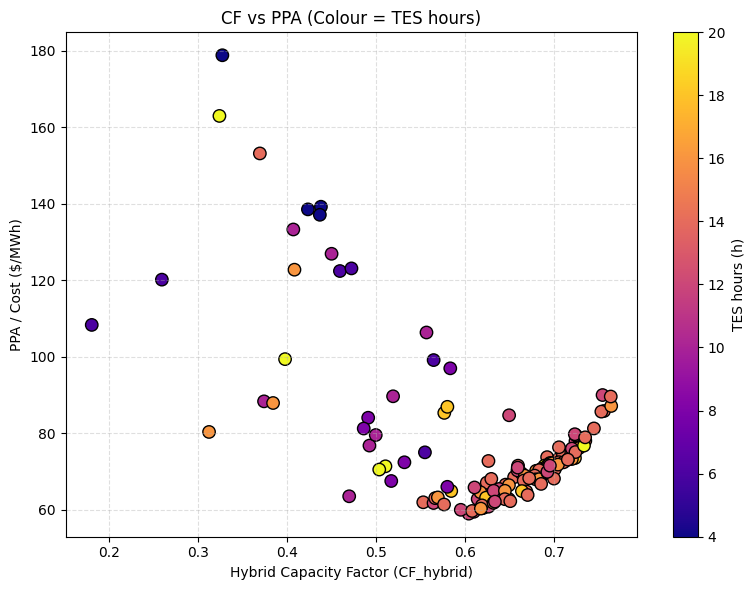

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the CSV file — replace 'your_file.csv' with your actual file path
df = pd.read_csv('deap_nsga_trials.csv')   # uses default parameters :contentReference[oaicite:0]{index=0}

# 2. Inspect first few rows to check column names
print(df.head())

# 3. Assume your columns are named, for example:
#    'CF_hybrid' for capacity factor,
#    'PPA_cost' for cost ($/MWh),
#    'TES_hours' for TES hours.
#    Adjust the column names below to match your CSV.

cf = df['CF_hybrid']
ppa = df['PPA']
tes = df['t_TES_hours']

# 4. Create the scatter plot
plt.figure(figsize=(8,6))
sc = plt.scatter(cf, ppa, c=tes, cmap = 'plasma', edgecolors='k', s=80)
cb = plt.colorbar(sc)
cb.set_label('TES hours (h)')

plt.xlabel('Hybrid Capacity Factor (CF_hybrid)')
plt.ylabel('PPA / Cost ($/MWh)')
plt.title('CF vs PPA (Colour = TES hours)')

# Option: invert y-axis if lower cost is better
# plt.gca().invert_yaxis()

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
